In [28]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE   = '/content/drive/MyDrive/CSC 566 - Advanced Data Mining/CSC-566-Final_Project_Mel_Spectrograms'
METADATA_DIR = f'{DRIVE_BASE}/metadata'
MELSPECS_DIR = f'{DRIVE_BASE}/melspecs'

os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(MELSPECS_DIR, exist_ok=True)

# Verify metadata TSV is present
TSV_PATH = f'{METADATA_DIR}/autotagging_moodtheme.tsv'
if not os.path.exists(TSV_PATH):
    print(f'WARNING: {TSV_PATH} not found.')
    print('Upload autotagging_moodtheme.tsv to the metadata/ folder in your Drive before continuing.')
else:
    print('Drive mounted and metadata found. Ready to go.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and metadata found. Ready to go.


In [29]:
!pip install librosa -q
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
import torch

In [30]:
import shutil
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

LOCAL_MELSPECS = '/content/melspecs'
os.makedirs(LOCAL_MELSPECS, exist_ok=True)

files = [f for f in os.listdir(MELSPECS_DIR) if f.endswith('.npy')][:5000]
print(f"Copying {len(files)} files...")

def copy_file(fname):
    src = os.path.join(MELSPECS_DIR, fname)
    dst = os.path.join(LOCAL_MELSPECS, fname)
    if not os.path.exists(dst):
        shutil.copy(src, dst)

with ThreadPoolExecutor(max_workers=8) as executor:
    list(tqdm(executor.map(copy_file, files), total=len(files), desc="Copying"))

print(f"Done! Files available: {len(os.listdir(LOCAL_MELSPECS))}")

Copying 5000 files...


Copying: 100%|██████████| 5000/5000 [00:00<00:00, 13736.64it/s]

Done! Files available: 5000


In [32]:
# Check for corrupted .npy files and remove them from both local and Drive
bad_files = []
for fname in os.listdir(LOCAL_MELSPECS):
    if not fname.endswith(".npy"):
        continue
    local_path = os.path.join(LOCAL_MELSPECS, fname)
    try:
        np.load(local_path, mmap_mode="r")
    except Exception as e:
        print(f"Bad: {fname} — {e}")
        bad_files.append(fname)

print(f"{len(bad_files)} corrupted files found.")
for fname in bad_files:
    os.remove(os.path.join(LOCAL_MELSPECS, fname))
    drive_path = os.path.join(MELSPECS_DIR, fname)
    if os.path.exists(drive_path):
        os.remove(drive_path)
    print(f"Deleted: {fname}")

if bad_files:
    print("Re-run the download cell to re-fetch corrupted files.")
else:
    print("All files OK.")


0 corrupted files found.
All files OK.


In [33]:
import pandas as pd

# MOOD/THEME TSV
rows = []
with open(TSV_PATH) as f:
    next(f)  # skip header
    for line in f:
        parts = line.rstrip('\n').split('\t')
        rows.append({
            'TRACK_ID':  parts[0],
            'ARTIST_ID': parts[1],
            'ALBUM_ID':  parts[2],
            'PATH':      parts[3],
            'DURATION':  float(parts[4]),
            'TAGS_MOOD': parts[5:],  # all remaining fields are tags
        })

df = pd.DataFrame(rows)
df.head()

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[mood/theme---background]
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[mood/theme---background]
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[mood/theme---background]
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic]


In [35]:
exploded_tags = df.explode('TAGS_MOOD')
tag_counts = exploded_tags['TAGS_MOOD'].value_counts()
filtered_tag_counts = tag_counts.head(20)
filtered_tag_counts
# Only keep rows that contain at least one top-20 tag.
# Tags outside the top 20 are dropped from each row's list.
top_tags = set(filtered_tag_counts.index)
df_filtered = df.copy()
df_filtered['TAGS_MOOD'] = df_filtered['TAGS_MOOD'].apply(lambda tags: [t for t in tags if t in top_tags])
df_filtered = df_filtered[df_filtered['TAGS_MOOD'].str.len() > 0]

print(f'Filtered dataset: {len(df_filtered)} tracks')
df_filtered.head()

Filtered dataset: 13881 tracks


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic]
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic]
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic]
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic]


(96, 10734)
(96, 9138)


<Figure size 1000x800 with 0 Axes>

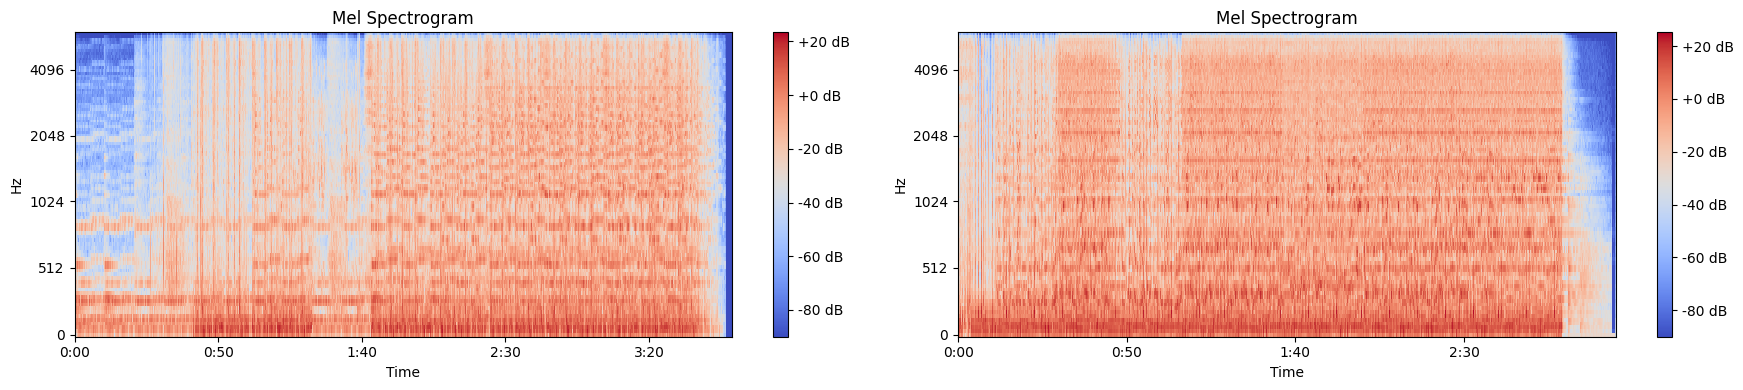

In [36]:
path = f'{MELSPECS_DIR}/'
mel1 = np.load(f"{path}2165.npy")
mel2 =  np.load(f"{path}3346.npy")
print(mel1.shape)
print(mel2.shape)

plt.figure(figsize=(10, 8))
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, mel, title in zip(axes, [mel1, mel2], ["Track 1", "Track 2"]):
    img = librosa.display.specshow(mel, x_axis='time', y_axis='mel', sr=12000, hop_length=256, ax=ax)                                       
    fig.colorbar(img, ax=ax, format='%+2.0f dB')                                                                                             
    ax.set_title("Mel Spectrogram")                                                                                                          
plt.tight_layout()                                                                                                                       
plt.show()       

* CNN Classifier for Mood/Theme
    * Multi-Label Classification Problem

In [37]:
# Label Encoding

# Top 20 Tags
top_tags = list(filtered_tag_counts.index)
tag_index_mapping = {tag: i for i, tag in enumerate(top_tags)}

# Encodes the Tags into a vector
def encode_labels(tags):
    label = np.zeros(len(tag_index_mapping), dtype=np.float32)
    for tag in tags:
        if tag in tag_index_mapping:
            label[tag_index_mapping[tag]] = 1.0
    return label

df_filtered['LABEL_ENCODING'] = df_filtered['TAGS_MOOD'].apply(encode_labels)
df_filtered.head()

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD,LABEL_ENCODING
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [38]:
from torch.utils.data import Dataset

CROP_LENGTH = 1366 # 29.1 second clip as per Won et ak. 2020 (standard used in the research papers)

class MoodDataset(Dataset):
    def __init__(self, df, melspecs_dir):
        self.df = df.reset_index(drop=True)
        self.melspecs_dir = melspecs_dir
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        track_id = int(row['TRACK_ID'].replace('track_', ''))
        npy_path = f"{self.melspecs_dir}/{track_id}.npy"
        mel = np.load(npy_path)
        if mel.shape[0] != 96:
            mel = mel.T  # transpose to (96, T)

        T = mel.shape[1]
        if T > CROP_LENGTH:
            start = np.random.randint(0, T - CROP_LENGTH)
            end = start + CROP_LENGTH
            mel = mel[:, start:end]
        else:
            pad = CROP_LENGTH - T
            mel = np.pad(mel, ((0, 0), (0, pad)))
        
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row['LABEL_ENCODING'], dtype=torch.float32)

        return mel, label

In [39]:
import torch.nn as nn

# Based off the FCN4 by Choi et al. 
"""
96 × 1366 × 1) → 
Conv 3×3×128 → 
MaxPool(2,4) → (48 × 341 × 128) → 
Conv 3×3×384 → MaxPool(4,5) → (24 × 85 × 384) → Conv 3×3×768 → MaxPool(3,8) → (12 × 21 × 768) → Conv 3×3×2048 → MaxPool(4,8) → (1 × 1 × 2048) → Sigmoid output (50 tags)
"""
class CNNClassificationModel(nn.Module):
    def __init__(self, num_tags=20):
        super(CNNClassificationModel, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,4))
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4,5))
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(384, 768, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(3,8))
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(768, 2048, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4,8))
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, num_tags),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        output_label = self.classifier(x)
        return output_label

    # Returns the 2048-dim embedding before the classifier
    def get_embedding(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        return x

In [40]:
model = CNNClassificationModel(num_tags=20)


In [41]:
from sklearn.model_selection import train_test_split

# Only keep tracks that exist in LOCAL_MELSPECS
def npy_exists(row):
    track_id = int(row['TRACK_ID'].replace('track_', ''))
    return os.path.exists(f"{LOCAL_MELSPECS}/{track_id}.npy")

df_available = df_filtered[df_filtered.apply(npy_exists, axis=1)].reset_index(drop=True)
print(f"Available tracks with local npy: {len(df_available)}")

# Split on available tracks only
df_train_val, df_test = train_test_split(df_available, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Available tracks with local npy: 5000
Train: 3200 | Val: 800 | Test: 1000


In [42]:
from torch.utils.data import DataLoader

train_dataset = MoodDataset(df_train,  LOCAL_MELSPECS)
val_dataset   = MoodDataset(df_val,   LOCAL_MELSPECS)
test_dataset  = MoodDataset(df_test,  LOCAL_MELSPECS)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 200
Val batches:   50
Test batches:  63


In [43]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = CNNClassificationModel(num_tags=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

NUM_EPOCHS = 5
best_val_auc = 0.0

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0

    for mels, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        mels   = mels.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(mels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    all_outputs = []
    all_labels  = []

    with torch.no_grad():
        for mels, labels in val_loader:
            mels   = mels.to(device)
            labels = labels.to(device)

            outputs = model(mels)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            all_outputs.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_labels  = np.concatenate(all_labels,  axis=0)

    roc_auc = roc_auc_score(all_labels, all_outputs, average='macro')
    pr_auc  = average_precision_score(all_labels, all_outputs, average='macro')

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} "
          f"| Train Loss: {train_loss/len(train_loader):.4f} "
          f"| Val Loss: {val_loss/len(val_loader):.4f} "
          f"| ROC-AUC: {roc_auc:.4f} "
          f"| PR-AUC: {pr_auc:.4f}")

    # Save best model
    if roc_auc > best_val_auc:
        best_val_auc = roc_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → Best model saved (ROC-AUC: {roc_auc:.4f})")

Using device: cuda


Epoch 1 Train: 100%|██████████| 200/200 [01:06<00:00,  3.00it/s]


Epoch 1/5 | Train Loss: 0.2679 | Val Loss: 0.2441 | ROC-AUC: 0.6571 | PR-AUC: 0.1315
  → Best model saved (ROC-AUC: 0.6571)


Epoch 2 Train: 100%|██████████| 200/200 [01:05<00:00,  3.07it/s]


Epoch 2/5 | Train Loss: 0.2471 | Val Loss: 0.2402 | ROC-AUC: 0.6691 | PR-AUC: 0.1469
  → Best model saved (ROC-AUC: 0.6691)


...

Epoch 3/5 | Train Loss: 0.2432 | Val Loss: 0.2404 | ROC-AUC: 0.6883 | PR-AUC: 0.1602
  → Best model saved (ROC-AUC: 0.6883)


Epoch 4 Train: 100%|██████████| 200/200 [01:06<00:00,  3.00it/s]


Epoch 4/5 | Train Loss: 0.2408 | Val Loss: 0.2334 | ROC-AUC: 0.6977 | PR-AUC: 0.1731
  → Best model saved (ROC-AUC: 0.6977)


Epoch 5 Train: 100%|██████████| 200/200 [01:05<00:00,  3.03it/s]


Epoch 5/5 | Train Loss: 0.2380 | Val Loss: 0.2334 | ROC-AUC: 0.7168 | PR-AUC: 0.1846
  → Best model saved (ROC-AUC: 0.7168)
